In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('2 Diwali Sales Data 2.csv',encoding='unicode_escape')

In [3]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [4]:
df.shape

(11251, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [6]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [7]:
df['Gender']=df['Gender'].replace('M','Male')

In [8]:
df['Gender']=df['Gender'].replace('F','Female')

In [9]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [10]:
df['Marital_Status']=df['Marital_Status'].replace(1,'Yes')
df['Marital_Status']=df['Marital_Status'].replace(0,'No')

In [11]:
df['Marital_Status'].unique()

array(['No', 'Yes'], dtype=object)

In [12]:
df=df.drop(columns=['Status','unnamed1'])

In [13]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [14]:
df.describe()

,User_ID,Age,Orders,Amount
count,1.125100e+04,11251.000000,11251.000000,11239.000000
mean,1.003004e+06,35.421207,2.489290,9453.610858
std,1.716125e+03,12.754122,1.115047,5222.355869
min,1.000001e+06,12.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,1.500000,5443.000000
50%,1.003065e+06,33.000000,2.000000,8109.000000
75%,1.004430e+06,43.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,4.000000,23952.000000


In [ ]:
 ax=sns.countplot(
    data=df,
    x='Gender',
    # hue='Amount'
)
for i in ax.containers:
    ax.bar_label(i)

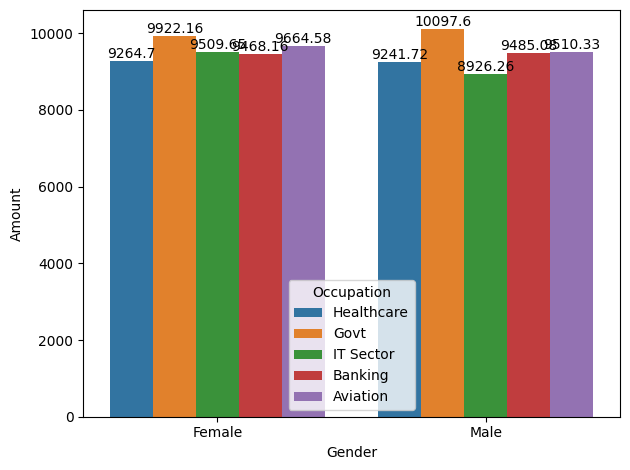

In [31]:
top_occupations = (
    df.groupby('Occupation')['Amount']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

df_top = df[df['Occupation'].isin(top_occupations)]

ax = sns.barplot(
    data=df_top,
    x='Gender',
    y='Amount',
    hue='Occupation',
    errorbar=None
)

for i in ax.containers:
    ax.bar_label(i)
# sns.despine()
plt.tight_layout()
plt.show()

In [18]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [33]:
sns.set_theme(style="whitegrid", palette="deep")

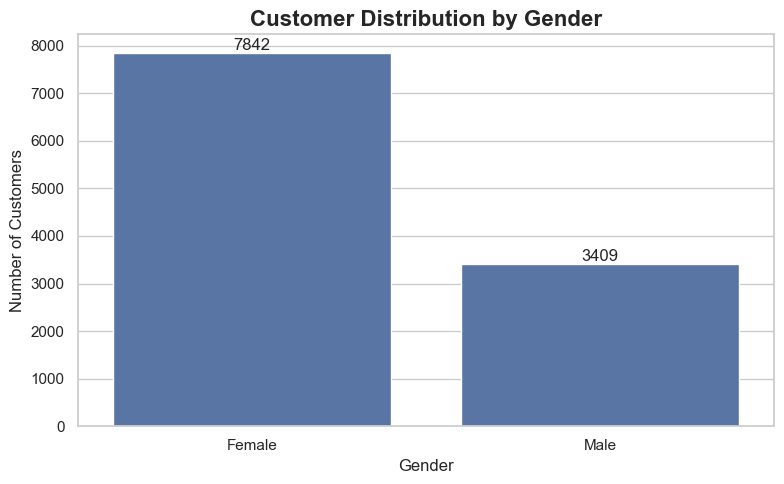

In [34]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Gender'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Customer Distribution by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

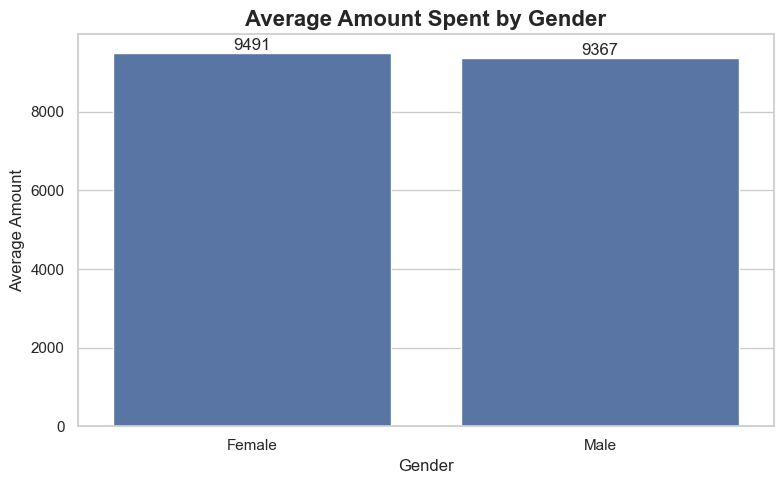

In [35]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x='Gender',
    y='Amount',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Average Amount Spent by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Amount')
plt.tight_layout()
plt.show()

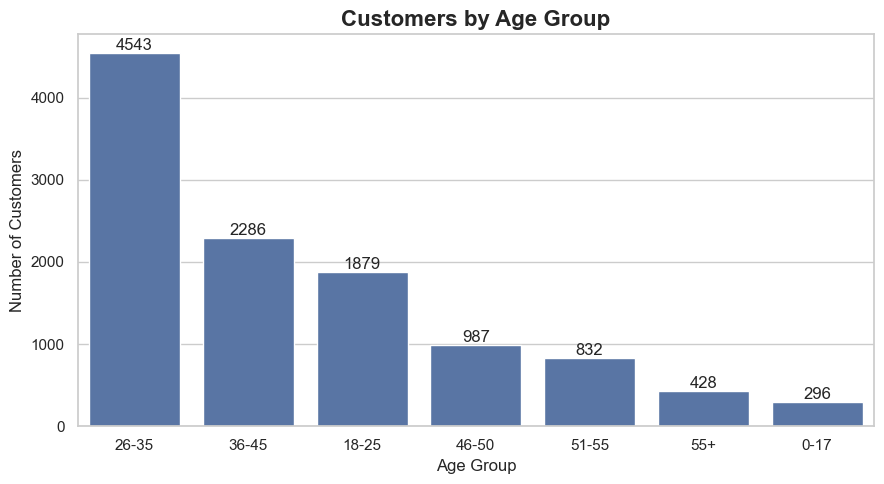

In [36]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df,
    x='Age Group',
    order=df['Age Group'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Customers by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

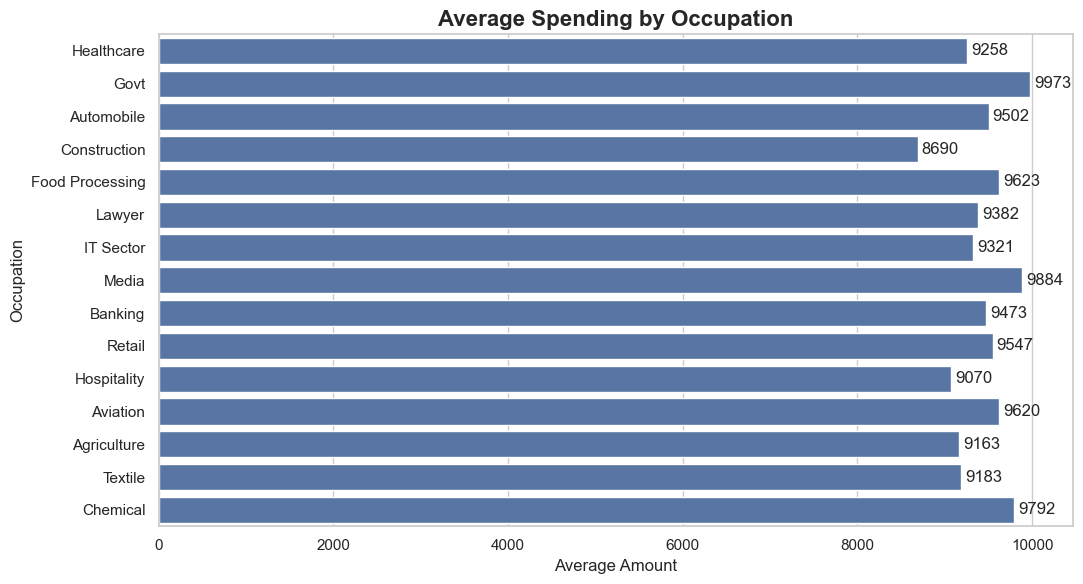

In [37]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=df,
    x='Amount',
    y='Occupation',
    estimator='mean',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Average Spending by Occupation', fontsize=16, fontweight='bold')
plt.xlabel('Average Amount')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()

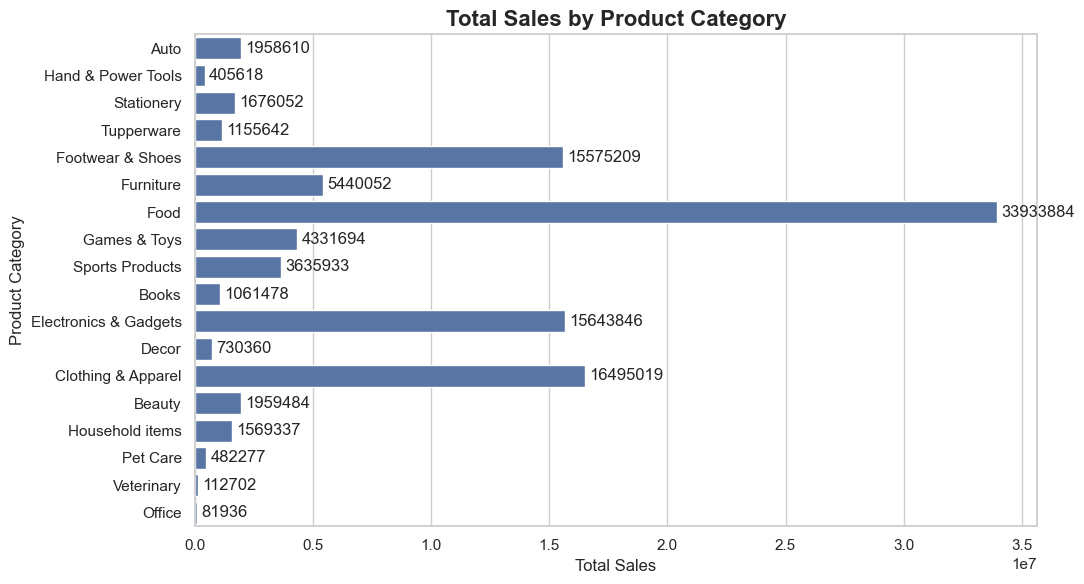

In [38]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=df,
    x='Amount',
    y='Product_Category',
    estimator='sum',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

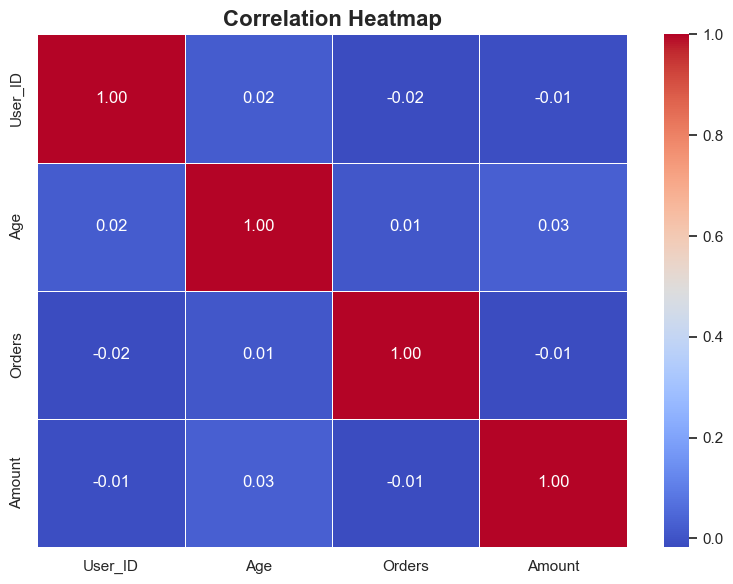

In [39]:
plt.figure(figsize=(8, 6))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()